# MLP with Manual L1 & L2 Regularization (Tabular Data, PyTorch)

In this notebook we:

- Use a **tabular dataset** (Breast Cancer Wisconsin) from `scikit-learn` (no images ✅).
- Build a simple **MLP classifier** with PyTorch.
- Implement **L1** and **L2** regularization **manually** inside the loss:
  - L1: sum of absolute values of weights.
  - L2: sum of squared weights.
- Compare the results of:
  - No regularization
  - L1 only
  - L2 only

## 1. Imports and Device Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
from pprint import pprint

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 2. Load a Tabular Dataset (No Images)

We use the **Breast Cancer Wisconsin** dataset:

- 569 samples
- 30 numeric features
- Binary classification: malignant (1) vs benign (0)

Steps:

1. Load data with `sklearn`.
2. Split into train/test.
3. Standardize features.
4. Convert to PyTorch tensors and wrap in `DataLoader`.

In [ ]:
# Load dataset
data = load_breast_cancer()
X = data.data      # shape: (n_samples, n_features)
y = data.target    # shape: (n_samples,)

print("Features shape:", X.shape)
print("Targets shape:", y.shape)
print("Classes:", data.target_names)

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features (important for MLP training)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Convert to torch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

# Create datasets and loaders
batch_size = 64

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

len(train_ds), len(test_ds)

Features shape: (569, 30)
Targets shape: (569,)
Classes: ['malignant' 'benign']


(455, 114)

## 3. Define the MLP Model (Fully-Connected Network)

Architecture:

- Input: 30 features
- Hidden layer 1: 64 units + ReLU
- Hidden layer 2: 32 units + ReLU
- Output: 2 units (for binary classification with `CrossEntropyLoss`)

In [3]:
class MLP(nn.Module):
    def __init__(self, input_dim: int, hidden1: int = 64, hidden2: int = 32, num_classes: int = 2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, num_classes)
        )

    def forward(self, x):
        return self.net(x)

input_dim = X_train.shape[1]
model_test = MLP(input_dim=input_dim).to(device)
print(model_test)

MLP(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=2, bias=True)
  )
)


## 4. Manual L1 and L2 Regularization in the Loss

We **do not** use `weight_decay` of the optimizer.

Instead:

- Base loss: `CrossEntropyLoss(outputs, labels)`
- L1 penalty: `l1_lambda * sum(|w| for all parameters)`
- L2 penalty: `l2_lambda * sum(w^2 for all parameters)`

Total loss:

\[
\text{loss} = \text{CE} + \lambda_1 \sum |w| + \lambda_2 \sum w^2
\]

In [4]:
def compute_l1_l2_penalty(model: nn.Module):
    """Return (l1, l2) penalties over all parameters."""
    l1 = 0.0
    l2 = 0.0
    for param in model.parameters():
        l1 = l1 + param.abs().sum()
        l2 = l2 + (param ** 2).sum()
    return l1, l2


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: optim.Optimizer,
    criterion: nn.Module,
    l1_lambda: float = 0.0,
    l2_lambda: float = 0.0
):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)

        # Base classification loss
        ce_loss = criterion(outputs, y_batch)

        # Manual L1 & L2 penalties
        l1_penalty, l2_penalty = compute_l1_l2_penalty(model)
        loss = ce_loss + l1_lambda * l1_penalty + l2_lambda * l2_penalty

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    epoch_loss = running_loss / total
    accuracy = correct / total
    return epoch_loss, accuracy


@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    l1_lambda: float = 0.0,
    l2_lambda: float = 0.0
):
    """We usually evaluate using only CE loss (without reg),
    but here we keep the same structure, with penalty if desired."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)
        ce_loss = criterion(outputs, y_batch)
        l1_penalty, l2_penalty = compute_l1_l2_penalty(model)
        loss = ce_loss + l1_lambda * l1_penalty + l2_lambda * l2_penalty

        running_loss += loss.item() * X_batch.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    epoch_loss = running_loss / total
    accuracy = correct / total
    return epoch_loss, accuracy

## 5. Experiment Runner

We define a function that:

- Builds a **fresh model**.
- Trains for some epochs.
- Uses manually tuned `l1_lambda` and `l2_lambda` (both scalars).
- Returns history for plotting and comparison.

In [5]:
def run_experiment(
    label: str,
    num_epochs: int = 30,
    l1_lambda: float = 0.0,
    l2_lambda: float = 0.0,
    learning_rate: float = 1e-3
):
    print(f"\n=== Experiment: {label} ===")
    print(f"L1 lambda: {l1_lambda}, L2 lambda: {l2_lambda}\n")

    model = MLP(input_dim=input_dim).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
    }

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            l1_lambda=l1_lambda,
            l2_lambda=l2_lambda
        )
        test_loss, test_acc = evaluate(
            model=model,
            loader=test_loader,
            criterion=criterion,
            l1_lambda=l1_lambda,
            l2_lambda=l2_lambda
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(
            f"Epoch {epoch:02d} | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}"
        )

    return history

## 6. Run Three Experiments

We will compare:

1. **No regularization**  
   - `l1_lambda = 0.0`
   - `l2_lambda = 0.0`

2. **L2 only**  
   - `l1_lambda = 0.0`
   - `l2_lambda = 1e-4` (you can tune)

3. **L1 only**  
   - `l1_lambda = 1e-5`
   - `l2_lambda = 0.0`

> For class: students can play with lambda values and number of epochs to see **underfitting / overfitting** behavior.


In [6]:
num_epochs = 30  # small dataset -> relatively fast

histories = {}

# 1) No regularization
histories["no_reg"] = run_experiment(
    label="No regularization",
    num_epochs=num_epochs,
    l1_lambda=0.0,
    l2_lambda=0.0
)

# 2) L2 only
histories["l2_only"] = run_experiment(
    label="L2 only",
    num_epochs=num_epochs,
    l1_lambda=0.0,
    l2_lambda=1e-4
)

# 3) L1 only
histories["l1_only"] = run_experiment(
    label="L1 only",
    num_epochs=num_epochs,
    l1_lambda=1e-5,
    l2_lambda=0.0
)


=== Experiment: No regularization ===
L1 lambda: 0.0, L2 lambda: 0.0

Epoch 01 | Train Loss: 0.6351, Train Acc: 0.6440 | Test Loss: 0.5837, Test Acc: 0.7544
Epoch 02 | Train Loss: 0.5448, Train Acc: 0.8571 | Test Loss: 0.4918, Test Acc: 0.9474
Epoch 03 | Train Loss: 0.4381, Train Acc: 0.9209 | Test Loss: 0.3830, Test Acc: 0.9561
Epoch 04 | Train Loss: 0.3268, Train Acc: 0.9385 | Test Loss: 0.2842, Test Acc: 0.9474
Epoch 05 | Train Loss: 0.2354, Train Acc: 0.9495 | Test Loss: 0.2098, Test Acc: 0.9474
Epoch 06 | Train Loss: 0.1743, Train Acc: 0.9516 | Test Loss: 0.1623, Test Acc: 0.9474
Epoch 07 | Train Loss: 0.1352, Train Acc: 0.9560 | Test Loss: 0.1348, Test Acc: 0.9474
Epoch 08 | Train Loss: 0.1099, Train Acc: 0.9670 | Test Loss: 0.1188, Test Acc: 0.9649
Epoch 09 | Train Loss: 0.0918, Train Acc: 0.9758 | Test Loss: 0.1088, Test Acc: 0.9649
Epoch 10 | Train Loss: 0.0803, Train Acc: 0.9758 | Test Loss: 0.1034, Test Acc: 0.9737
Epoch 11 | Train Loss: 0.0703, Train Acc: 0.9868 | Test Los

## 7. Plot Loss and Accuracy

We plot:

- Training and test **loss**
- Training and test **accuracy**

for each regularization setting.

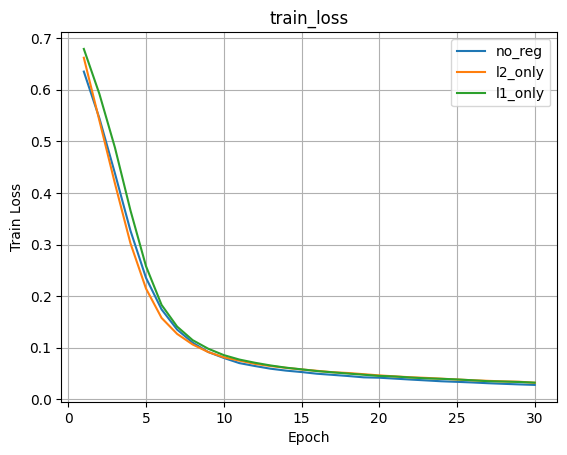

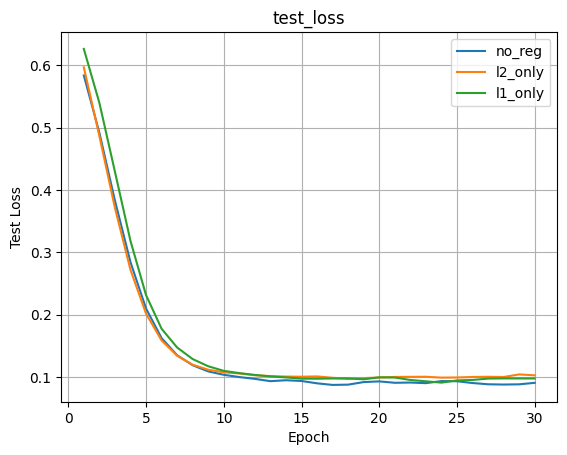

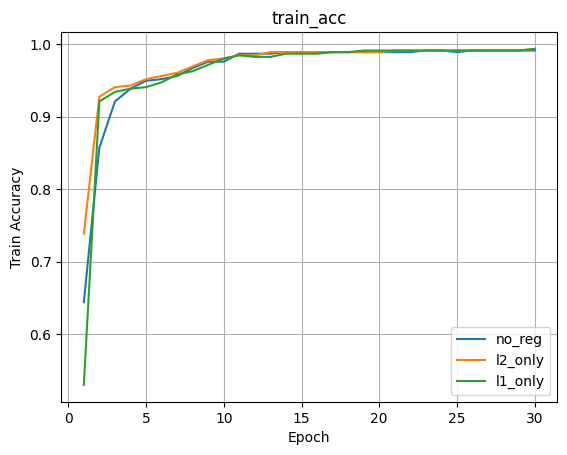

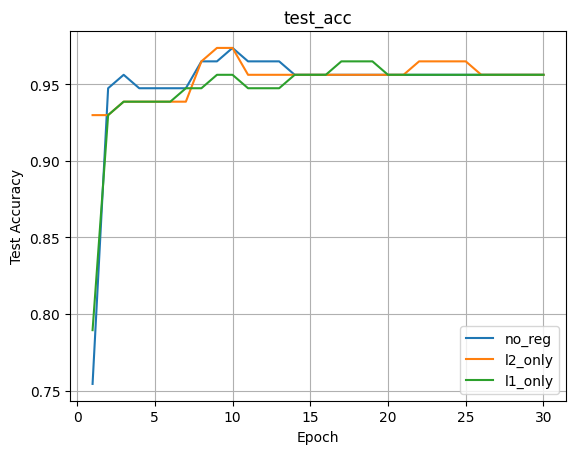

In [7]:
def plot_metric(histories, key, ylabel):
    plt.figure()
    for name, hist in histories.items():
        values = hist[key]
        epochs = range(1, len(values) + 1)
        plt.plot(epochs, values, label=name)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(key)
    plt.legend()
    plt.grid(True)
    plt.show()

# Loss
plot_metric(histories, "train_loss", "Train Loss")
plot_metric(histories, "test_loss", "Test Loss")

# Accuracy
plot_metric(histories, "train_acc", "Train Accuracy")
plot_metric(histories, "test_acc", "Test Accuracy")

## 8. Final Numerical Comparison

We print the **last epoch** results for each experiment, so students can easily compare.

In [8]:
summary = {}
for name, hist in histories.items():
    summary[name] = {
        "final_train_loss": hist["train_loss"][-1],
        "final_train_acc": hist["train_acc"][-1],
        "final_test_loss": hist["test_loss"][-1],
        "final_test_acc": hist["test_acc"][-1],
    }

print("=== Final Epoch Summary ===")
pprint(summary)

=== Final Epoch Summary ===
{'l1_only': {'final_test_acc': 0.956140350877193,
             'final_test_loss': 0.09750468545315559,
             'final_train_acc': 0.9934065934065934,
             'final_train_loss': 0.032399084345325006},
 'l2_only': {'final_test_acc': 0.956140350877193,
             'final_test_loss': 0.10254848990262601,
             'final_train_acc': 0.9934065934065934,
             'final_train_loss': 0.03216607672581961},
 'no_reg': {'final_test_acc': 0.956140350877193,
            'final_test_loss': 0.09054356225227055,
            'final_train_acc': 0.9912087912087912,
            'final_train_loss': 0.02797963383433583}}
